In [22]:
import torch
from torch.autograd import Variable as V
import torchvision.models as models
from torchvision import transforms as trn
from torch.nn import functional as F
from torchvision import transforms as T
import os
import torchvision
import numpy as np
import cv2
from PIL import Image

# Hacky way to deal with the Pytorch 1.0 update
def recursion_change_bn(module):
    if isinstance(module, torch.nn.BatchNorm2d):
        module.track_running_stats = 1
    else:
        for i, (name, module1) in enumerate(module._modules.items()):
            module1 = recursion_change_bn(module1)
    return module

def load_labels():
    # Prepare all the labels
    file_name_category = 'categories_places365.txt'
    if not os.path.exists(file_name_category):
        synset_url = 'https://raw.githubusercontent.com/csailvision/places365/master/categories_places365.txt'
        !wget $synset_url  # Download using !wget in Colab
    classes = list()
    with open(file_name_category) as class_file:
        for line in class_file:
            classes.append(line.strip().split(' ')[0][3:])
    classes = tuple(classes)

    # Indoor and outdoor relevant
    file_name_IO = 'IO_places365.txt'
    if not os.path.exists(file_name_IO):
        synset_url = 'https://raw.githubusercontent.com/csailvision/places365/master/IO_places365.txt'
        !wget $synset_url  # Download using !wget in Colab
    with open(file_name_IO) as f:
        lines = f.readlines()
        labels_IO = []
        for line in lines:
            items = line.rstrip().split()
            labels_IO.append(int(items[-1]) - 1)  # 0 is indoor, 1 is outdoor
    labels_IO = np.array(labels_IO)

    # Scene attribute relevant
    file_name_attribute = 'labels_sunattribute.txt'
    if not os.path.exists(file_name_attribute):
        synset_url = 'https://raw.githubusercontent.com/csailvision/places365/master/labels_sunattribute.txt'
        !wget $synset_url  # Download using !wget in Colab
    with open(file_name_attribute) as f:
        lines = f.readlines()
        labels_attribute = [item.rstrip() for item in lines]

    file_name_W = 'W_sceneattribute_wideresnet18.npy'
    if not os.path.exists(file_name_W):
        synset_url = 'http://places2.csail.mit.edu/models_places365/W_sceneattribute_wideresnet18.npy'
        !wget $synset_url  # Download using !wget in Colab
    W_attribute = np.load(file_name_W)

    return classes, labels_IO, labels_attribute, W_attribute

def hook_feature(module, input, output):
    features_blobs.append(np.squeeze(output.data.cpu().numpy()))

def returnCAM(feature_conv, weight_softmax, class_idx):
    # Generate the class activation maps upsampled to 256x256
    size_upsample = (256, 256)
    nc, h, w = feature_conv.shape
    cam = weight_softmax[class_idx].dot(feature_conv.reshape((nc, h * w)))
    cam = cam.reshape(h, w)
    cam = cam - np.min(cam)
    cam_img = cam / np.max(cam)
    cam_img = np.uint8(255 * cam_img)
    return cv2.resize(cam_img, size_upsample)

def returnTF():
    # Load the image transformer
    tf = trn.Compose([
        trn.Resize((224, 224)),
        trn.ToTensor(),
        trn.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    return tf

def load_model():
    model_file = 'wideresnet18_places365.pth.tar'
    if not os.path.exists(model_file):
        !wget http://places2.csail.mit.edu/models_places365/$model_file
        !wget https://raw.githubusercontent.com/csailvision/places365/master/wideresnet.py

    import wideresnet  # This needs to be dynamically imported after download
    model = wideresnet.resnet18(num_classes=365)
    checkpoint = torch.load(model_file, map_location=lambda storage, loc: storage)
    state_dict = {str.replace(k, 'module.', ''): v for k, v in checkpoint['state_dict'].items()}
    model.load_state_dict(state_dict)

    for i, (name, module) in enumerate(model._modules.items()):
        module = recursion_change_bn(model)
    model.avgpool = torch.nn.AvgPool2d(kernel_size=14, stride=1, padding=0)

    model.eval()

    features_names = ['layer4', 'avgpool']  # Hook the feature extractor
    for name in features_names:
        model._modules.get(name).register_forward_hook(hook_feature)
    return model

# Load the labels and model
classes, labels_IO, labels_attribute, W_attribute = load_labels()
features_blobs = []
model = load_model()
tf = returnTF()

# Get the softmax weight
params = list(model.parameters())
weight_softmax = params[-2].data.numpy()
weight_softmax[weight_softmax < 0] = 0

# Load Faster R-CNN object detection model
def load_object_detection_model():
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)
    model.eval()
    return model

# Detect objects function
def detect_objects(image, model):
    # Transform image for detection
    transform = T.ToTensor()
    img_tensor = transform(image)


    # Run object detection
    with torch.no_grad():
        predictions = model([img_tensor])

    scores=predictions[0]['scores']
    labels=predictions[0]['labels']
    num=torch.argwhere(scores>0.7).shape[0]


    # Filter predictions by confidence threshold
    detected_objects = []
    for i in range(num):
        class_name=coco_names[labels.numpy()[i]-1]
        if class_name not in detected_objects:
          detected_objects.append(class_name)


    return detected_objects



# Category names for COCO dataset used by Faster R-CNN
coco_names = ["person" , "bicycle" , "car" , "motorcycle" , "airplane" , "bus" , "train" , "truck" , "boat" , "traffic light" , "fire hydrant" , "street sign" , "stop sign" , "parking meter" , "bench" , "bird" , "cat" , "dog" , "horse" , "sheep" , "cow" , "elephant" , "bear" , "zebra" , "giraffe" , "hat" , "backpack" , "umbrella" , "shoe" , "eye glasses" , "handbag" , "tie" , "suitcase" ,
"frisbee" , "skis" , "snowboard" , "sports ball" , "kite" , "baseball bat" ,
"baseball glove" , "skateboard" , "surfboard" , "tennis racket" , "bottle" ,
"plate" , "wine glass" , "cup" , "fork" , "knife" , "spoon" , "bowl" ,
"banana" , "apple" , "sandwich" , "orange" , "broccoli" , "carrot" , "hot dog" ,
"pizza" , "donut" , "cake" , "chair" , "couch" , "potted plant" , "bed" ,
"mirror" , "dining table" , "window" , "desk" , "toilet" , "door" , "tv" ,
"laptop" , "mouse" , "remote" , "keyboard" , "cell phone" , "microwave" ,
"oven" , "toaster" , "sink" , "refrigerator" , "blender" , "book" ,
"clock" , "vase" , "scissors" , "teddy bear" , "hair drier" , "toothbrush" , "hair brush"]

# Combined function for scene and object detection
def analyze_image_with_detection(img_path):
    img = Image.open(img_path)
    input_img = V(tf(img).unsqueeze(0))

    # Forward pass for scene analysis
    logit = model.forward(input_img)
    h_x = F.softmax(logit, 1).data.squeeze()
    probs, idx = h_x.sort(0, True)
    probs, idx = probs.numpy(), idx.numpy()

    top_scene_idx = idx[0]
    top_scene_prob = probs[0]
    top_scene_name = classes[top_scene_idx]

    # Run object detection
    object_detection_model = load_object_detection_model()  # Load Faster R-CNN model
    detected_objects = detect_objects(img, object_detection_model)

    # Display detected objects
    print(f'--DETECTED OBJECTS: {", ".join(detected_objects)}')

    # Determine indoor or outdoor
    io_image = labels_IO[top_scene_idx]
    environment = "indoor" if io_image == 0 else "outdoor"
    print(f'--TYPE OF ENVIRONMENT: {environment}')

    # Output the scene category
    print(f'--SCENE CATEGORY: {top_scene_name} ---> {top_scene_prob:.3f}')

    # Output scene attributes
    responses_attribute = W_attribute.dot(features_blobs[1])
    idx_a = np.argsort(responses_attribute)
    scene_attributes = ', '.join([labels_attribute[idx_a[i]] for i in range(-1, -10, -1)])
    print(f'--SCENE ATTRIBUTES: {scene_attributes}')

    # Generate class activation mapping
    CAM = returnCAM(features_blobs[0], weight_softmax, top_scene_idx)

    # Render and save the CAM
    img_cv2 = cv2.imread(img_path)
    height, width, _ = img_cv2.shape
    heatmap = cv2.applyColorMap(cv2.resize(CAM, (width, height)), cv2.COLORMAP_JET)
    result = heatmap * 0.4 + img_cv2 * 0.5
    cv2.imwrite('cam.jpg', result)
    print('Class activation map is saved as cam.jpg')

# Example usage
analyze_image_with_detection('/content/bedroon.jpg')


<ipython-input-22-af3489ef9051>:95: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_file, map_location=lambda storage, loc: storage)
/usr/local/l

--DETECTED OBJECTS: potted plant, bed, cup, chair, vase
--TYPE OF ENVIRONMENT: indoor
--SCENE CATEGORY: bedroom ---> 0.387
--SCENE ATTRIBUTES: no horizon, man-made, enclosed area, wood, reading, soothing, cloth, glass, natural light
Class activation map is saved as cam.jpg


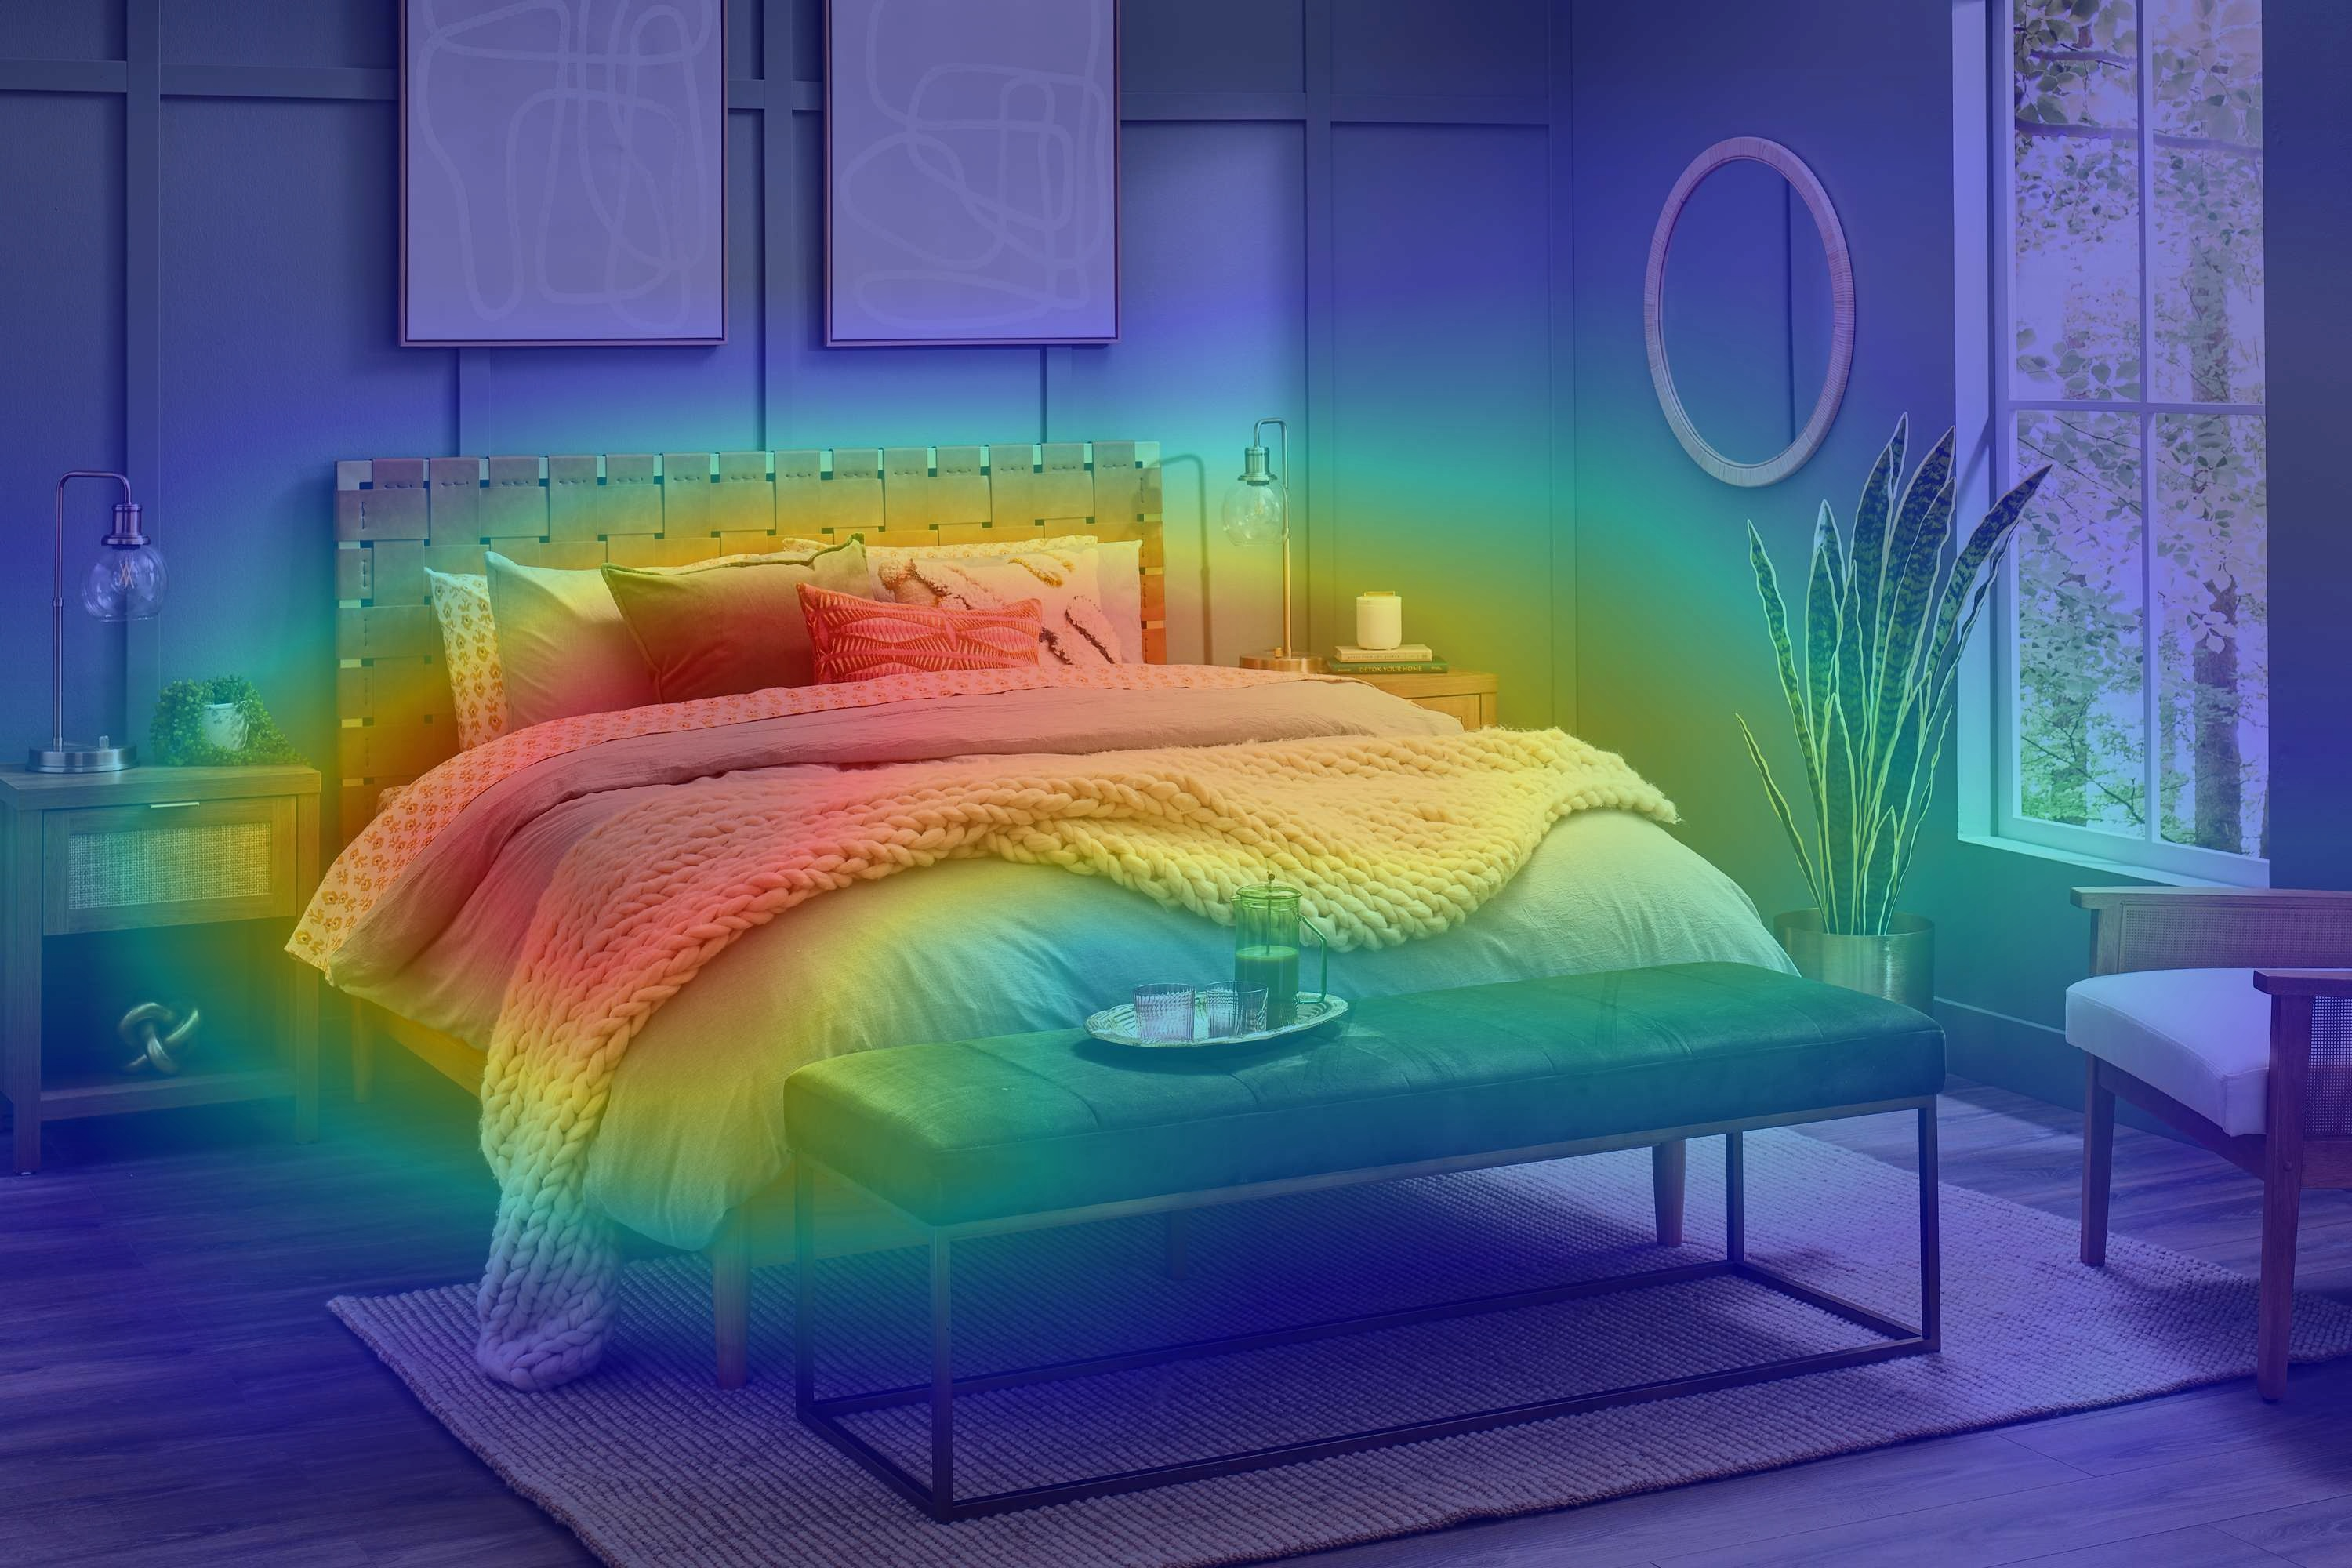

In [24]:
import cv2
from google.colab.patches import cv2_imshow
path = '/content/cam.jpg'
image = cv2.imread(path)
cv2_imshow( image)